<a href="https://colab.research.google.com/github/ThanhVy02/PhanTichDuLieuNangCao/blob/main/baitapchuong3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Tải và làm sạch ban đầu dữ liệu...
Thông tin DataFrame sau khi làm sạch ban đầu:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 9471 entries, 2004-03-10 18:00:00 to NaT
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   CO(GT)         2137 non-null   float64
 1   PT08.S1(CO)    8991 non-null   float64
 2   NMHC(GT)       914 non-null    float64
 3   C6H6(GT)       0 non-null      float64
 4   PT08.S2(NMHC)  8991 non-null   float64
 5   NOx(GT)        7718 non-null   float64
 6   PT08.S3(NOx)   8991 non-null   float64
 7   NO2(GT)        7715 non-null   float64
 8   PT08.S4(NO2)   8991 non-null   float64
 9   PT08.S5(O3)    8991 non-null   float64
 10  T              366 non-null    float64
 11  RH             366 non-null    float64
 12  AH             366 non-null    float64
dtypes: float64(13)
memory usage: 1.0 MB

2. Xử lý các giá trị bị thiếu...
Tỷ lệ phần trăm giá trị bị thiếu của mỗi cột:
 CO(GT) 

,PT08.S1(CO),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3)
DateTime,,,,,,,
2004-03-10 18:00:00,1360.0,1046.0,166.0,1056.0,113.0,1692.0,1268.0
2004-03-10 19:00:00,1292.0,955.0,103.0,1174.0,92.0,1559.0,972.0
2004-03-10 20:00:00,1402.0,939.0,131.0,1140.0,114.0,1555.0,1074.0
2004-03-10 21:00:00,1376.0,948.0,172.0,1092.0,122.0,1584.0,1203.0
2004-03-10 22:00:00,1272.0,836.0,131.0,1205.0,116.0,1490.0,1110.0



3. Kỹ thuật tính năng...
Cột 'Hour' đã được thêm vào.

4. Trực quan hóa dữ liệu...
  Tạo biểu đồ chuỗi thời gian...


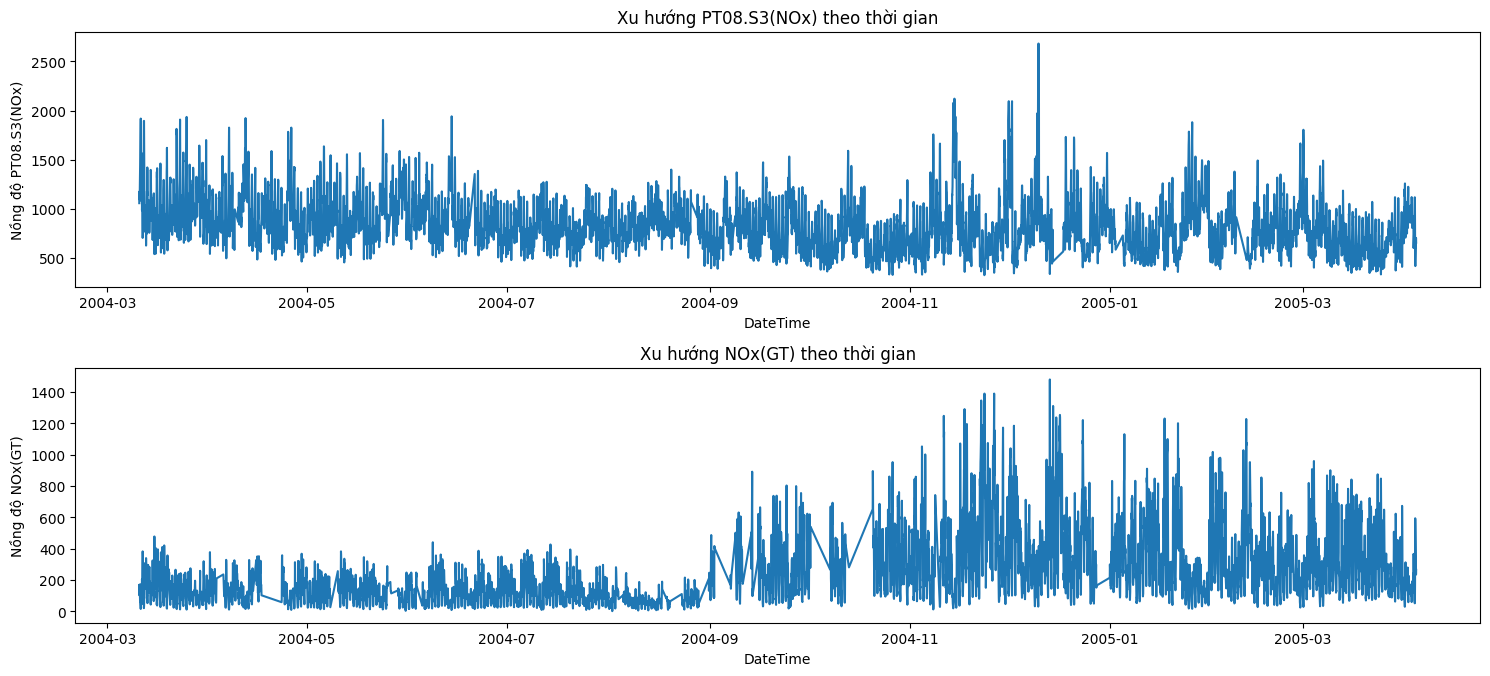

  Tạo biểu đồ phân phối...


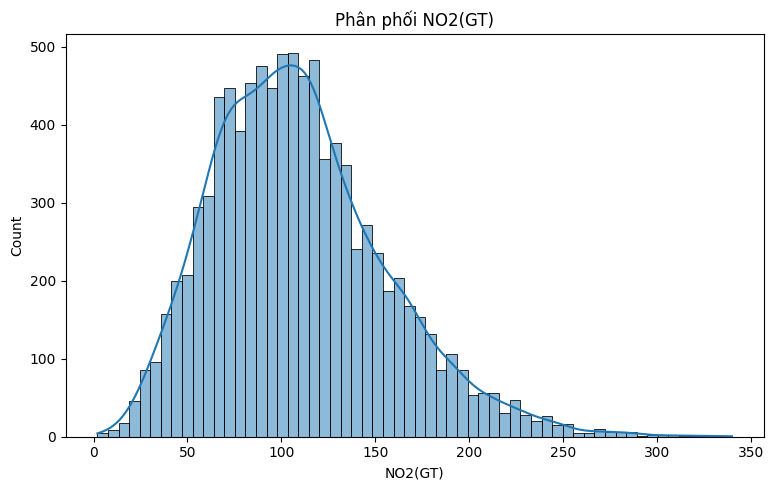

  Tạo biểu đồ hộp theo giờ...


<Figure size 1500x500 with 0 Axes>

  Tạo ma trận tương quan...


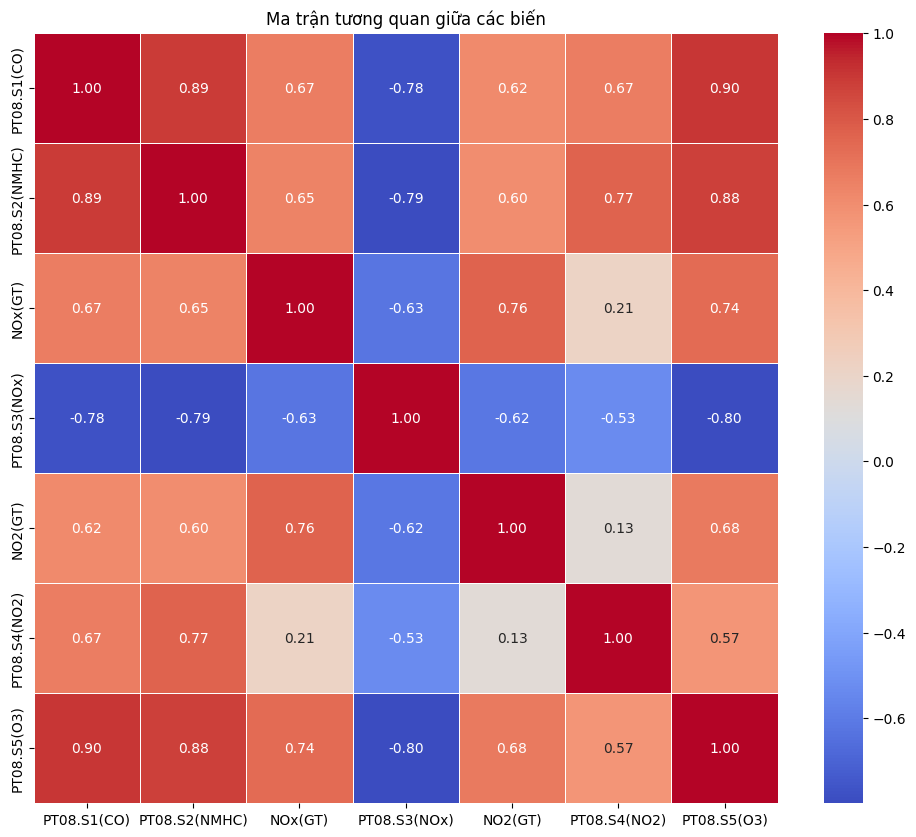


Quy trình hoàn tất!


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Tải và làm sạch ban đầu dữ liệu ---
print('1. Tải và làm sạch ban đầu dữ liệu...')
df = pd.read_csv('/content/AirQualityUCI.csv', sep=';')

# Loại bỏ hai cột cuối cùng hoàn toàn NaN và tạo một bản sao để tránh SettingWithCopyWarning
df = df.iloc[:, :-2].copy()

# Kết hợp các cột 'Date' và 'Time' để tạo chỉ mục datetime
df['DateTime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], format='%d/%m/%Y %H.%M.%S', errors='coerce')

# Đặt DateTime làm chỉ mục và sắp xếp
df = df.set_index('DateTime').sort_index()

# Loại bỏ các cột 'Date' và 'Time' ban đầu
df = df.drop(columns=['Date', 'Time'])

# Thay thế -200 bằng NaN (chỉ báo giá trị bị thiếu phổ biến trong bộ dữ liệu này)
df = df.replace(-200, np.nan)

# Chuyển đổi các cột liên quan sang kiểu số, xử lý lỗi thành NaN
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print('Thông tin DataFrame sau khi làm sạch ban đầu:')
df.info()

# --- 2. Xử lý các giá trị bị thiếu ---
print('\n2. Xử lý các giá trị bị thiếu...')

# Loại bỏ các hàng có chỉ mục DateTime là NaT
df = df[df.index.notna()]

# Tính tỷ lệ phần trăm bị thiếu cho mỗi cột
missing_percentage = df.isnull().sum() / len(df) * 100
print('Tỷ lệ phần trăm giá trị bị thiếu của mỗi cột:\n', missing_percentage)

# Loại bỏ các cột có hơn 70% giá trị bị thiếu (ngưỡng có thể điều chỉnh)
columns_to_drop = missing_percentage[missing_percentage > 70].index.tolist()
if columns_to_drop:
    df = df.drop(columns=columns_to_drop)
    print(f'Các cột bị xóa do có hơn 70% giá trị bị thiếu: {columns_to_drop}')
else:
    print('Không có cột nào bị xóa do có hơn 70% giá trị bị thiếu.')

# Nội suy các giá trị bị thiếu còn lại bằng nội suy tuyến tính
df = df.interpolate(method='linear', limit_direction='both')

# Xác minh không còn giá trị bị thiếu
print('\nThông tin DataFrame sau khi xử lý các giá trị bị thiếu:')
df.info()

# Hiển thị vài hàng đầu tiên sau khi làm sạch
print('\nDataFrame sau khi làm sạch và xử lý giá trị bị thiếu:')
display(df.head())

# --- 3. Kỹ thuật tính năng ---
print('\n3. Kỹ thuật tính năng...')
# Trích xuất giờ để tìm các mẫu hàng giờ
df['Hour'] = df.index.hour
print('Cột \'Hour\' đã được thêm vào.')

# --- 4. Trực quan hóa dữ liệu ---
print('\n4. Trực quan hóa dữ liệu...')

# Trực quan hóa 4.1: Biểu đồ chuỗi thời gian cho các chất ô nhiễm chính
print('  Tạo biểu đồ chuỗi thời gian...')
plt.figure(figsize=(15, 10))

# Đảm bảo các cột tồn tại trước khi cố gắng vẽ biểu đồ
if 'CO(GT)' in df.columns:
    plt.subplot(3, 1, 1)
    sns.lineplot(data=df, x=df.index, y='CO(GT)')
    plt.title('Xu hướng CO(GT) theo thời gian')
    plt.ylabel('Nồng độ CO(GT)')

if 'PT08.S3(NOx)' in df.columns:
    plt.subplot(3, 1, 2)
    sns.lineplot(data=df, x=df.index, y='PT08.S3(NOx)')
    plt.title('Xu hướng PT08.S3(NOx) theo thời gian')
    plt.ylabel('Nồng độ PT08.S3(NOx)')

if 'NOx(GT)' in df.columns:
    plt.subplot(3, 1, 3)
    sns.lineplot(data=df, x=df.index, y='NOx(GT)')
    plt.title('Xu hướng NOx(GT) theo thời gian')
    plt.ylabel('Nồng độ NOx(GT)')

plt.tight_layout()
plt.show()

# Trực quan hóa 4.2: Biểu đồ phân phối cho các chất ô nhiễm chính
print('  Tạo biểu đồ phân phối...')
plt.figure(figsize=(15, 5))

if 'C6H6(GT)' in df.columns:
    plt.subplot(1, 2, 1)
    sns.histplot(df['C6H6(GT)'], kde=True)
    plt.title('Phân phối C6H6(GT)')

if 'NO2(GT)' in df.columns:
    plt.subplot(1, 2, 2)
    sns.histplot(df['NO2(GT)'], kde=True)
    plt.title('Phân phối NO2(GT)')

plt.tight_layout()
plt.show()

# Trực quan hóa 4.3: Biểu đồ hộp theo giờ trong ngày
print('  Tạo biểu đồ hộp theo giờ...')
plt.figure(figsize=(15, 5))

if 'CO(GT)' in df.columns and 'Hour' in df.columns:
    plt.subplot(1, 2, 1)
    sns.boxplot(data=df, x='Hour', y='CO(GT)')
    plt.title('CO(GT) theo giờ trong ngày')
    plt.ylabel('Nồng độ CO(GT)')

if 'T' in df.columns and 'Hour' in df.columns:
    plt.subplot(1, 2, 2)
    sns.boxplot(data=df, x='Hour', y='T')
    plt.title('Nhiệt độ (T) theo giờ trong ngày')
    plt.ylabel('Nhiệt độ (°C)')

plt.tight_layout()
plt.show()

# Trực quan hóa 4.4: Ma trận tương quan
print('  Tạo ma trận tương quan...')
# Đảm bảo cột 'Hour' không được sử dụng để tính tương quan nếu không phù hợp
columns_for_corr = df.drop(columns=['Hour'], errors='ignore').select_dtypes(include=np.number).columns
if len(columns_for_corr) > 1:
    correlation_matrix = df[columns_for_corr].corr()

    plt.figure(figsize=(12, 10))
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
    plt.title('Ma trận tương quan giữa các biến')
    plt.show()
else:
    print('Không đủ cột số để tạo ma trận tương quan.')

print('\nQuy trình hoàn tất!')